# Prediccion del Precio Futuro de TSLA
## Proyecto de Machine Learning - Regresion Lineal

**Instituto Tecnologico de Las Americas (ITLA)**  
**Curso:** Inteligencia Artificial  
**Profesor:** Ramon E. Alvarez S.  

---

### Pipeline del Proyecto
1. Recoleccion de Datos (API Alpaca)
2. Preprocesamiento y  CaracterÃ­sticas
3. Analisis Exploratorio de Datos (EDA)
4. Entrenamiento de 8 Modelos de Regresion
5. Evaluacion y Comparacion
6. Prediccion con Nuevos Datos

---
## PARTE 1: RECOLECCION Y PREPROCESAMIENTO DE DATOS
### Responsable: Persona 1

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("ALPACA_API_KEY")
secret_key = os.getenv("ALPACA_SECRET_KEY")

print("Keys cargadas:", api_key is not None, secret_key is not None)

Keys cargadas: True True


In [2]:
!pip install alpaca-py


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime

In [5]:
client = StockHistoricalDataClient(api_key, secret_key)

In [6]:
request_params = StockBarsRequest(
    symbol_or_symbols="TSLA",
    timeframe=TimeFrame.Day,
    start=datetime(2020, 1, 1),
    end=datetime(2026, 7, 21)
)

bars = client.get_stock_bars(request_params)
df = bars.df

print(df.shape)
df.head()

(1644, 7)


open      high      low   close  \
symbol timestamp                                                      
TSLA   2020-01-02 05:00:00+00:00  424.50  430.6957  421.710  430.26   
       2020-01-03 05:00:00+00:00  440.50  454.0000  436.920  443.01   
       2020-01-06 05:00:00+00:00  440.47  451.5600  440.000  451.50   
       2020-01-07 05:00:00+00:00  461.40  471.6300  453.355  469.06   
       2020-01-08 05:00:00+00:00  473.70  498.4900  468.230  492.14   

                                      volume  trade_count        vwap  
symbol timestamp                                                       
TSLA   2020-01-02 05:00:00+00:00   9763456.0     136851.0  427.117489  
       2020-01-03 05:00:00+00:00  18034327.0     236310.0  446.323497  
       2020-01-06 05:00:00+00:00  10362505.0     134223.0  445.863261  
       2020-01-07 05:00:00+00:00  18488930.0     250189.0  464.051044  
       2020-01-08 05:00:00+00:00  31486817.0     413644.0  485.693897

In [7]:
df.to_csv("../data/raw/tsla_raw.csv")
print("Guardado correctamente")

Guardado correctamente


In [8]:

df = df.sort_index()

# 1. Retorno diario (% de cambio respecto al d├¡a anterior)
df['retorno_diario'] = df['close'].pct_change()

# 2. Media m├│vil de 5 d├¡as
df['sma_5'] = df['close'].rolling(window=5).mean()

# 3. Media m├│vil de 20 d├¡as
df['sma_20'] = df['close'].rolling(window=20).mean()

# 4. Volatilidad (desviaci├│n est├indar de 5 d├¡as)
df['volatilidad_5'] = df['close'].rolling(window=5).std()

# 5. Volumen promedio de 5 d├¡as
df['volumen_promedio_5'] = df['volume'].rolling(window=5).mean()

# 6. Precio de cierre del d├¡a anterior (lag)
df['precio_anterior'] = df['close'].shift(1)

# Variable objetivo: precio de cierre del d├¡a SIGUIENTE
df['precio_futuro'] = df['close'].shift(-1)

print(df.shape)
df.head(10)

(1644, 14)


open      high       low   close  \
symbol timestamp                                                        
TSLA   2020-01-02 05:00:00+00:00  424.500  430.6957  421.7100  430.26   
       2020-01-03 05:00:00+00:00  440.500  454.0000  436.9200  443.01   
       2020-01-06 05:00:00+00:00  440.470  451.5600  440.0000  451.50   
       2020-01-07 05:00:00+00:00  461.400  471.6300  453.3550  469.06   
       2020-01-08 05:00:00+00:00  473.700  498.4900  468.2300  492.14   
       2020-01-09 05:00:00+00:00  497.100  498.8000  472.8700  481.34   
       2020-01-10 05:00:00+00:00  481.790  484.9400  473.7000  478.15   
       2020-01-13 05:00:00+00:00  493.500  525.6300  492.0000  524.86   
       2020-01-14 05:00:00+00:00  544.255  547.4100  524.9000  537.92   
       2020-01-15 05:00:00+00:00  529.760  537.8400  516.7853  518.50   

                                      volume  trade_count        vwap  \
symbol timestamp                                                        
TSLA   2020-01-02 05:00:00+00:00   9763456.0     136851.0  427.117489   
       2020-01-03 05:00:00+00:00  18034327.0     236310.0  446.323497   
       2020-01-06 05:00:00+00:00  10362505.0     134223.0  445.863261   
       2020-01-07 05:00:00+00:00  18488930.0     250189.0  464.051044   
       2020-01-08 05:00:00+00:00  31486817.0     413644.0  485.693897   
       2020-01-09 05:00:00+00:00  28959816.0     384282.0  485.533718   
       2020-01-10 05:00:00+00:00  13217075.0     181667.0  478.804229   
       2020-01-13 05:00:00+00:00  26916914.0     369915.0  511.288547   
       2020-01-14 05:00:00+00:00  29600289.0     406428.0  538.125989   
       2020-01-15 05:00:00+00:00  17643746.0     261961.0  529.061934   

                                  retorno_diario    sma_5  sma_20  \
symbol timestamp                                                    
TSLA   2020-01-02 05:00:00+00:00             NaN      NaN     NaN   
       2020-01-03 05:00:00+00:00        0.029633      NaN     NaN   
       2020-01-06 05:00:00+00:00        0.019164      NaN     NaN   
       2020-01-07 05:00:00+00:00        0.038893      NaN     NaN   
       2020-01-08 05:00:00+00:00        0.049205  457.194     NaN   
       2020-01-09 05:00:00+00:00       -0.021945  467.410     NaN   
       2020-01-10 05:00:00+00:00       -0.006627  474.438     NaN   
       2020-01-13 05:00:00+00:00        0.097689  489.110     NaN   
       2020-01-14 05:00:00+00:00        0.024883  502.882     NaN   
       2020-01-15 05:00:00+00:00       -0.036102  508.154     NaN   

                                  volatilidad_5  volumen_promedio_5  \
symbol timestamp                                                      
TSLA   2020-01-02 05:00:00+00:00            NaN                 NaN   
       2020-01-03 05:00:00+00:00            NaN                 NaN   
       2020-01-06 05:00:00+00:00            NaN                 NaN   
       2020-01-07 05:00:00+00:00            NaN                 NaN   
       2020-01-08 05:00:00+00:00      24.088756          17627207.0   
       2020-01-09 05:00:00+00:00      20.352079          21466479.0   
       2020-01-10 05:00:00+00:00      15.246738          20503028.6   
       2020-01-13 05:00:00+00:00      21.620247          23813910.4   
       2020-01-14 05:00:00+00:00      26.934244          26036182.2   
       2020-01-15 05:00:00+00:00      26.885756          23267568.0   

                                  precio_anterior  precio_futuro  
symbol timestamp                                                  
TSLA   2020-01-02 05:00:00+00:00              NaN         443.01  
       2020-01-03 05:00:00+00:00           430.26         451.50  
       2020-01-06 05:00:00+00:00           443.01         469.06  
       2020-01-07 05:00:00+00:00           451.50         492.14  
       2020-01-08 05:00:00+00:00           469.06         481.34  
       2020-01-09 05:00:00+00:00           492.14         478.15  
       2020-01-10 05:00:00+00:00           481.34         524.86 

In [9]:
# Ver cu├intos nulos hay por columna
print(df.isnull().sum())

# Eliminar filas con valores nulos
df_limpio = df.dropna()

print("Antes:", df.shape)
print("Despu├®s de limpiar:", df_limpio.shape)

open                   0
high                   0
low                    0
close                  0
volume                 0
trade_count            0
vwap                   0
retorno_diario         1
sma_5                  4
sma_20                19
volatilidad_5          4
volumen_promedio_5     4
precio_anterior        1
precio_futuro          1
dtype: int64
Antes: (1644, 14)
Despu├®s de limpiar: (1624, 14)


In [10]:
from sklearn.preprocessing import StandardScaler

# Definimos qu├® columnas son nuestras features (X) y cu├il es el objetivo (y)
features = ['open', 'high', 'low', 'close', 'volume', 'retorno_diario',
            'sma_5', 'sma_20', 'volatilidad_5', 'volumen_promedio_5', 'precio_anterior']

X = df_limpio[features]
y = df_limpio['precio_futuro']

# Escalar las features
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print("Forma de X escalado:", X_escalado.shape)
print("Forma de y:", y.shape)

Forma de X escalado: (1624, 11)
Forma de y: (1624,)


In [11]:
import pandas as pd


df_final = pd.DataFrame(X_escalado, columns=features)
df_final['precio_futuro'] = y.values


df_final.to_csv("../data/processed/tsla_processed.csv", index=False)

print("Dataset final guardado correctamente")
print(df_final.shape)
df_final.head()

Dataset final guardado correctamente
(1624, 12)


,open,high,low,close,volume,retorno_diario,sma_5,sma_20,volatilidad_5,volumen_promedio_5,precio_anterior,precio_futuro
0,0.429893,0.437281,0.436630,0.455516,-0.877272,2.114542,0.276856,0.091213,0.284992,-1.181532,0.270217,650.57
1,0.453347,0.443657,0.482922,0.485687,-1.147637,0.290142,0.330429,0.126750,0.480616,-1.175817,0.455141,780.00
2,0.557587,0.844040,0.613636,0.885793,-0.505550,4.110606,0.469113,0.181108,1.340841,-1.030915,0.485313,887.06
3,1.205094,1.393913,1.124888,1.216747,-0.224783,2.827700,0.669137,0.251366,2.161437,-0.818096,0.885425,734.70
4,1.020375,1.023993,0.711164,0.745757,-0.478977,-3.598348,0.765169,0.294215,1.695284,-0.686598,1.216384,748.96


---
## PARTE 2: ANÃLISIS EXPLORATORIO DE DATOS (EDA)
### Responsable: Persona 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/tsla_processed.csv')
df.head()

In [2]:
print('Filas y columnas:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nRegistros duplicados:', df.duplicated().sum())

Filas y columnas: (1624, 12)

Tipos de datos:
open                  float64
high                  float64
low                   float64
close                 float64
volume                float64
retorno_diario        float64
sma_5                 float64
sma_20                float64
volatilidad_5         float64
volumen_promedio_5    float64
precio_anterior       float64
precio_futuro         float64
dtype: object

Valores nulos por columna:
open                  0
high                  0
low                   0
close                 0
volume                0
retorno_diario        0
sma_5                 0
sma_20                0
volatilidad_5         0
volumen_promedio_5    0
precio_anterior       0
precio_futuro         0
dtype: int64

Registros duplicados: 0


In [3]:
estadisticas = df.describe().T
estadisticas['mediana'] = df.median(numeric_only=True)
estadisticas

,count,mean,std,min,25%,50%,75%,max,mediana
open,1624.0,3.500211e-17,1.000308,-1.208195,-0.776249,-0.290805,0.650891,5.574485,-0.290805
high,1624.0,-1.400084e-16,1.000308,-1.184011,-0.777508,-0.290663,0.643600,5.452182,-0.290663
low,1624.0,7.000421e-17,1.000308,-1.209062,-0.780479,-0.285454,0.651213,5.437311,-0.285454
close,1624.0,-1.050063e-16,1.000308,-1.191249,-0.780477,-0.286411,0.655924,5.395221,-0.286411
volume,1624.0,-7.000421e-17,1.000308,-1.367812,-0.877362,-0.167874,0.622551,4.785585,-0.167874
retorno_diario,1624.0,-9.844342e-18,1.000308,-16.140057,-0.448406,0.004826,0.438632,4.691860,0.004826
sma_5,1624.0,1.050063e-16,1.000308,-1.189228,-0.788096,-0.281612,0.665674,5.107086,-0.281612
sma_20,1624.0,-7.000421e-17,1.000308,-1.203186,-0.816390,-0.277049,0.675017,4.101808,-0.277049
volatilidad_5,1624.0,1.750105e-17,1.000308,-0.400084,-0.288324,-0.200738,0.040302,19.613704,-0.200738
volumen_promedio_5,1624.0,4.200253e-16,1.000308,-1.404913,-0.917139,-0.099298,0.679818,3.584384,-0.099298


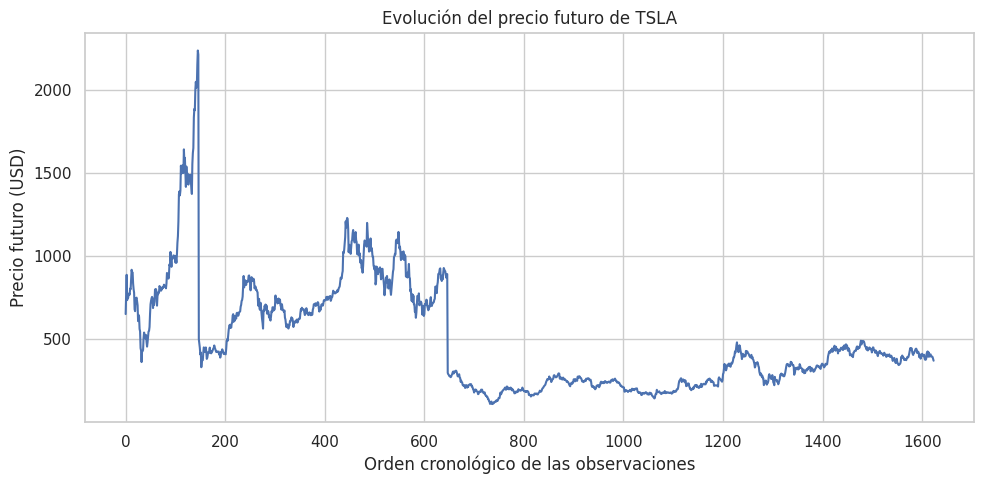

In [4]:
plt.figure(figsize=(10,5))
sns.lineplot(x=np.arange(len(df)), y=df['precio_futuro'])
plt.title('EvoluciÃ³n del precio futuro de TSLA')
plt.xlabel('Orden cronolÃ³gico de las observaciones')
plt.ylabel('Precio futuro (USD)')
plt.tight_layout()
plt.show()

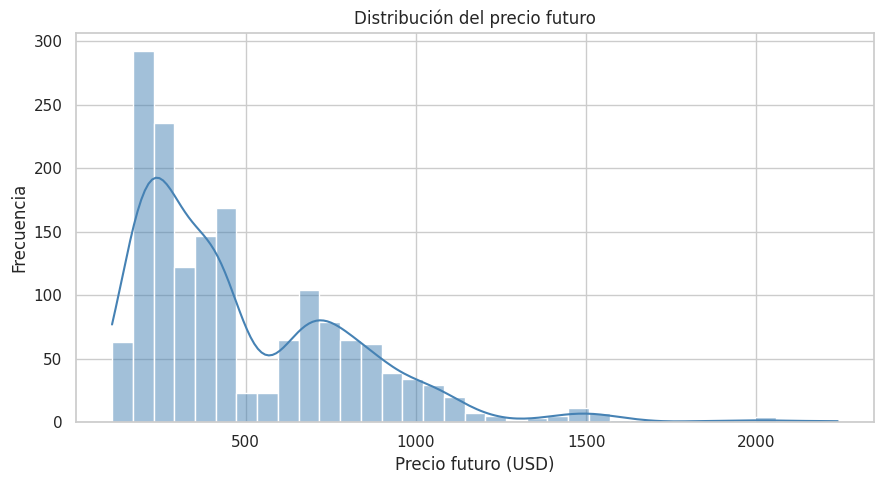

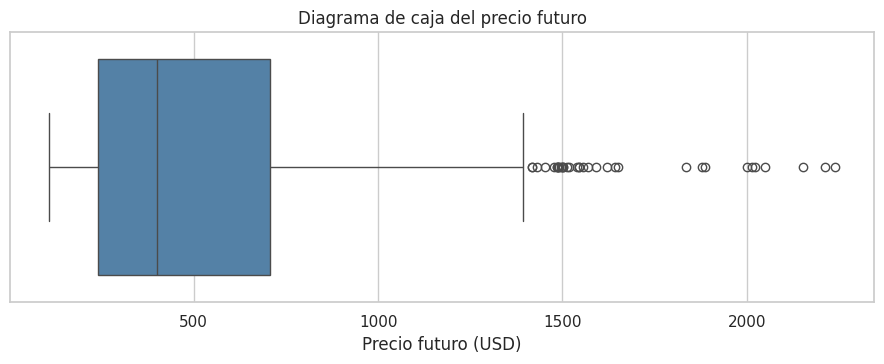

In [5]:
plt.figure(figsize=(9,5))
sns.histplot(df['precio_futuro'], bins=35, kde=True, color='steelblue')
plt.title('DistribuciÃ³n del precio futuro')
plt.xlabel('Precio futuro (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,3.8))
sns.boxplot(x=df['precio_futuro'], color='steelblue')
plt.title('Diagrama de caja del precio futuro')
plt.xlabel('Precio futuro (USD)')
plt.tight_layout()
plt.show()

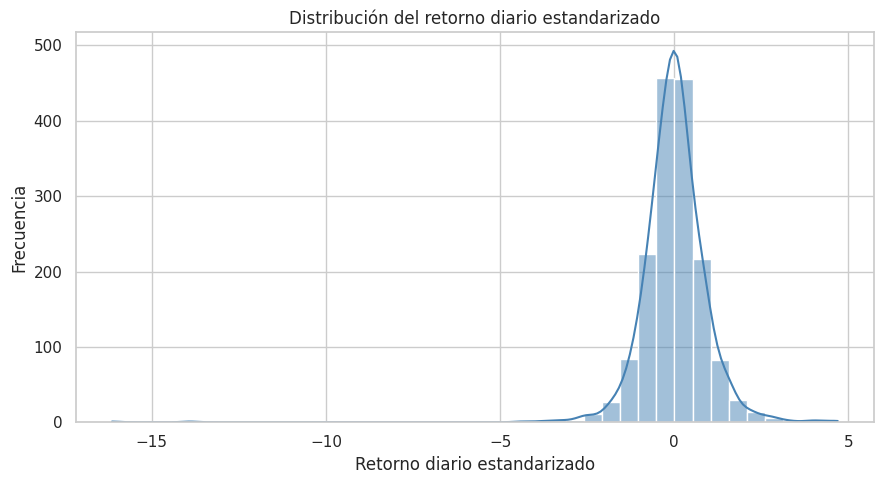

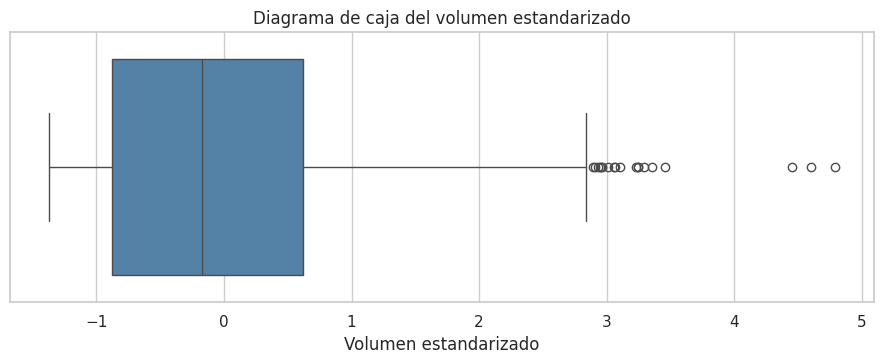

In [6]:
plt.figure(figsize=(9,5))
sns.histplot(df['retorno_diario'], bins=40, kde=True, color='steelblue')
plt.title('DistribuciÃ³n del retorno diario estandarizado')
plt.xlabel('Retorno diario estandarizado')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,3.8))
sns.boxplot(x=df['volume'],color='steelblue')
plt.title('Diagrama de caja del volumen estandarizado')
plt.xlabel('Volumen estandarizado')
plt.tight_layout()
plt.show()

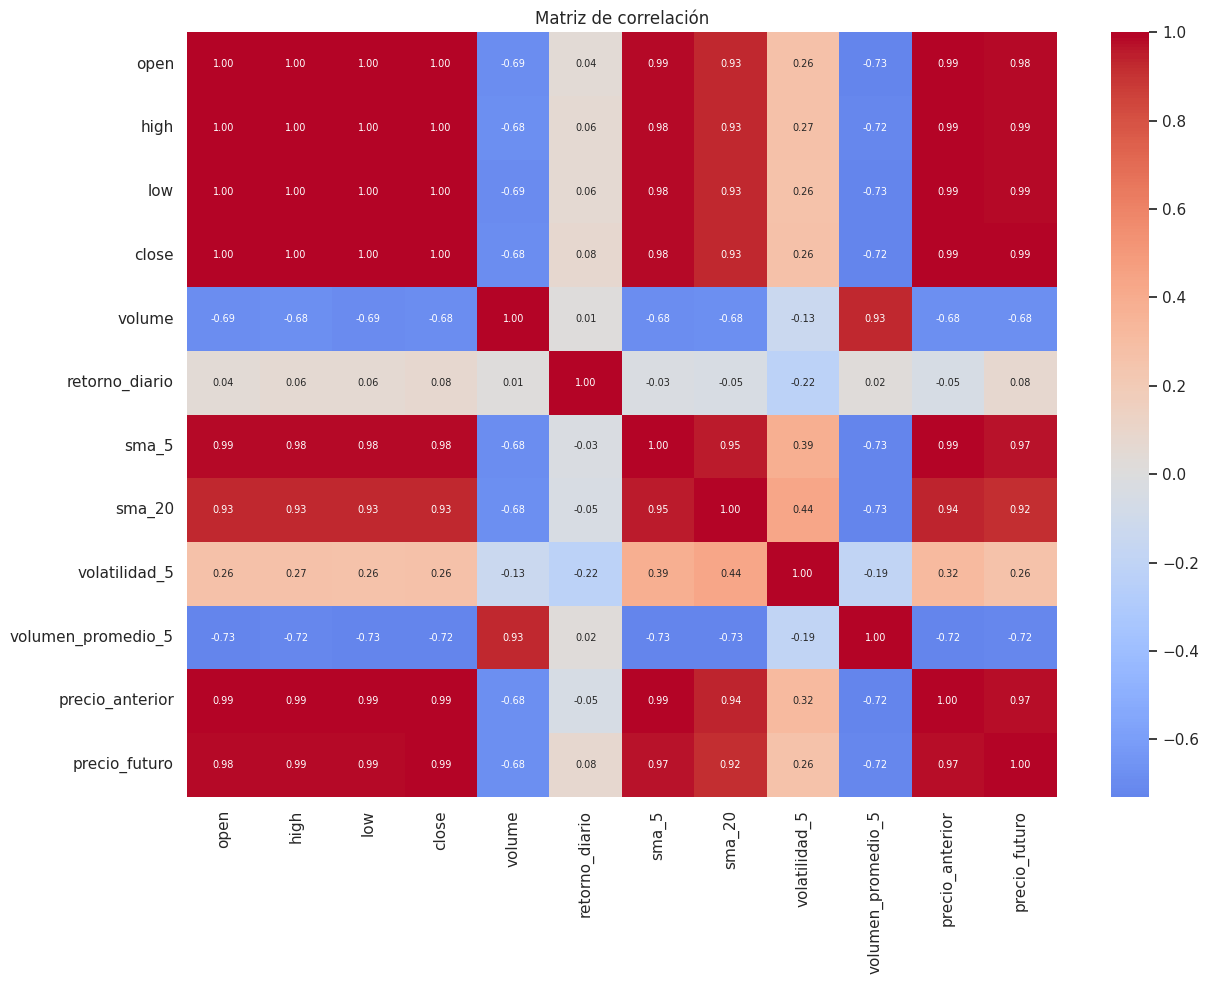

close                 0.987264
low                   0.986020
high                  0.985412
open                  0.984163
precio_anterior       0.973987
sma_5                 0.971515
sma_20                0.917010
volatilidad_5         0.258397
retorno_diario        0.077157
volume               -0.682607
volumen_promedio_5   -0.722510
Name: precio_futuro, dtype: float64

In [7]:
correlacion = df.corr(numeric_only=True)

plt.figure(figsize=(13,10))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Matriz de correlaciÃ³n')
plt.tight_layout()
plt.show()

correlacion_objetivo = (
    correlacion['precio_futuro']
    .drop('precio_futuro')
    .sort_values(ascending=False)
)
correlacion_objetivo

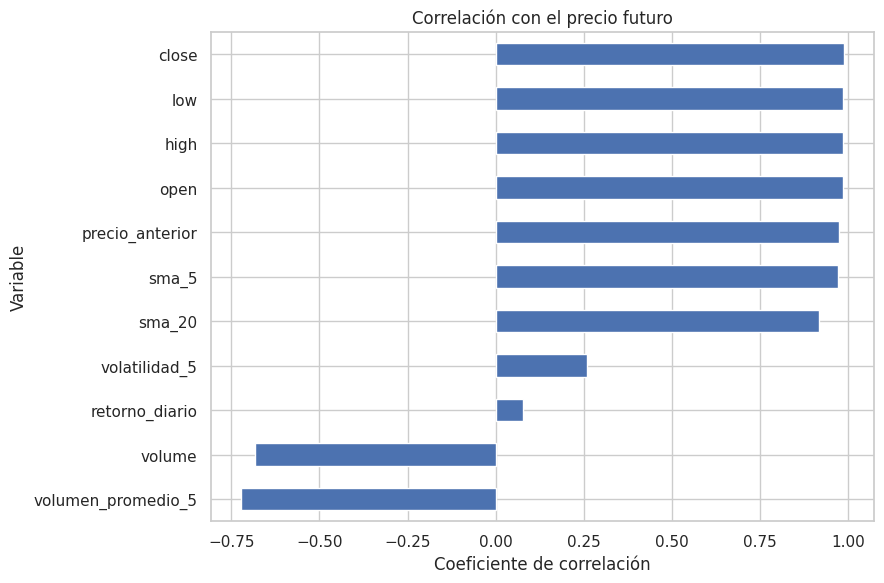

In [8]:
plt.figure(figsize=(9,6))
correlacion_objetivo.sort_values().plot(kind='barh')
plt.title('CorrelaciÃ³n con el precio futuro')
plt.xlabel('Coeficiente de correlaciÃ³n')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

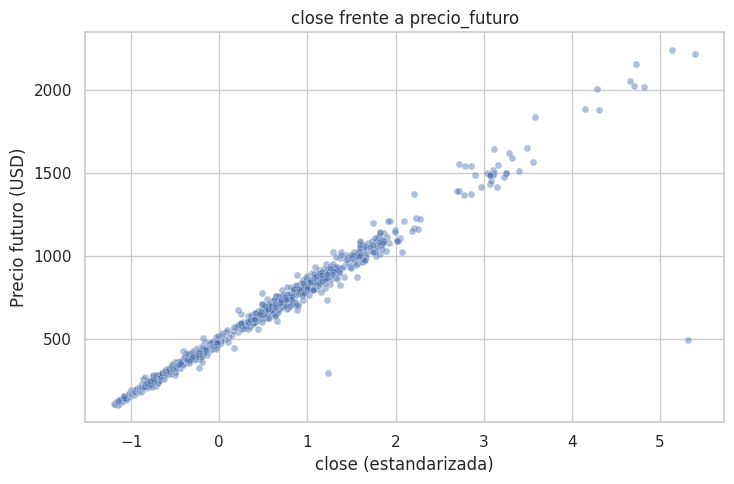

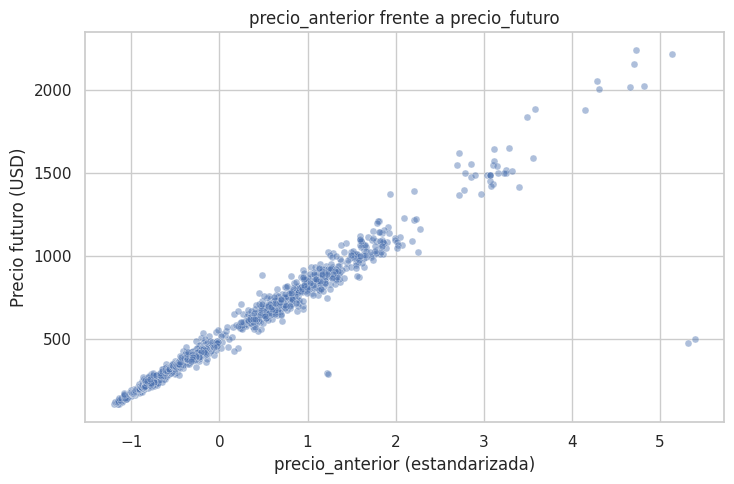

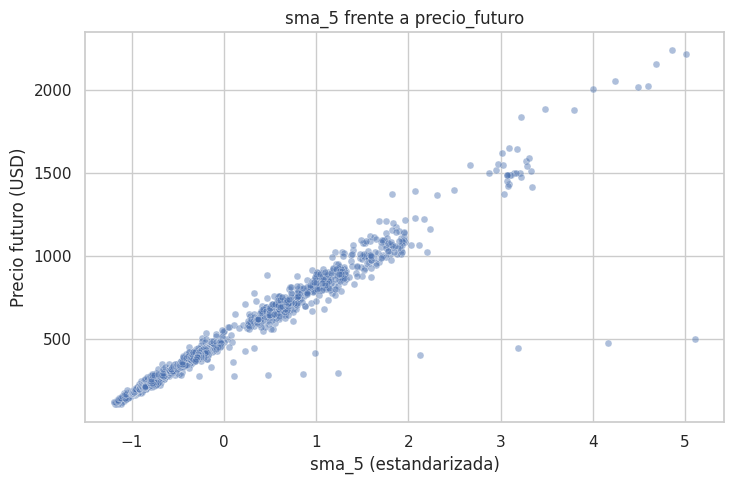

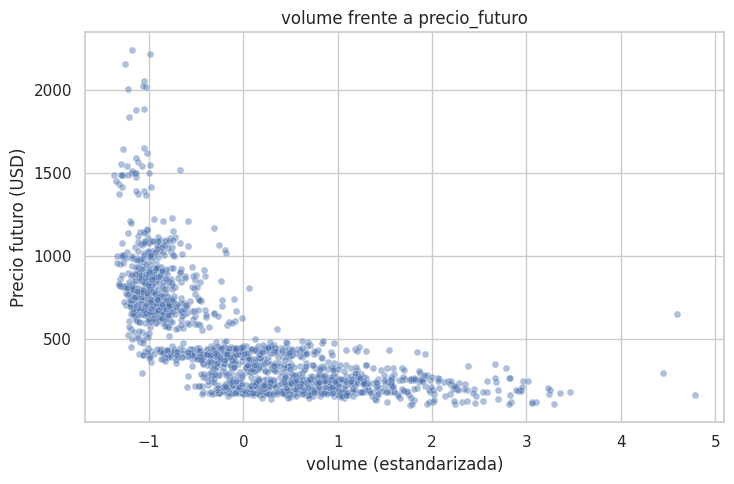

In [9]:
variables = ['close', 'precio_anterior', 'sma_5', 'volume']

for variable in variables:
    plt.figure(figsize=(7.5,5))
    sns.scatterplot(data=df, x=variable, y='precio_futuro', alpha=0.45, s=25)
    plt.title(f'{variable} frente a precio_futuro')
    plt.xlabel(f'{variable} (estandarizada)')
    plt.ylabel('Precio futuro (USD)')
    plt.tight_layout()
    plt.show()

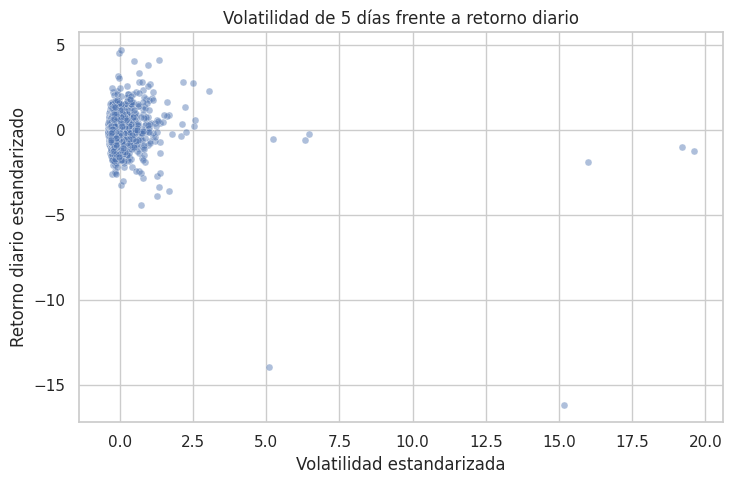

In [10]:
plt.figure(figsize=(7.5,5))
sns.scatterplot(data=df, x='volatilidad_5', y='retorno_diario', alpha=0.45, s=25)
plt.title('Volatilidad de 5 dÃ­as frente a retorno diario')
plt.xlabel('Volatilidad estandarizada')
plt.ylabel('Retorno diario estandarizado')
plt.tight_layout()
plt.show()

### ConclusiÃ³n del EDA

El dataset estÃ¡ limpio y cumple con el tamaÃ±o solicitado. Las variables mÃ¡s relacionadas con el precio futuro son las vinculadas al nivel reciente del precio: apertura, mÃ¡ximo, mÃ­nimo, cierre, precio anterior y medias mÃ³viles. El retorno, la volatilidad y el volumen aportan una perspectiva diferente sobre los cambios, el riesgo y la actividad del mercado.

---
## PARTE 3: ENTRENAMIENTO DE MODELOS DE REGRESIÃ“N
### Responsables: Persona 3 y Persona 4

**Modelos a entrenar:**
1. OLS (Linear Regression)
2. Ridge Regression
3. Lasso Regression
4. Bayesian Regression
5. KNN Regression
6. Random Forest Regression
7. SVM Regression
8. Neural Network MLP Regression

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rutas_posibles = [
    '../data/processed/tsla_processed.csv',
    '../../data/processed/tsla_processed.csv',
    'data/processed/tsla_processed.csv',
    'tsla_processed.csv'
]

ruta_encontrada = None
for ruta in rutas_posibles:
    if os.path.exists(ruta):
        ruta_encontrada = ruta
        break

if ruta_encontrada:
    df = pd.read_csv(ruta_encontrada)
    print(f"Dataset cargado correctamente desde: {os.path.abspath(ruta_encontrada)}")
    print(f"Dimensiones del dataset: {df.shape}")
else:
    raise FileNotFoundError("No se encontrÃ³ 'tsla_processed.csv'. Verifica que el archivo estÃ© en la carpeta data/processed/")

X = df.drop(columns=['precio_futuro'])
y = df['precio_futuro']

split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nRegistros de entrenamiento (Train): {len(X_train)}")
print(f"Registros de prueba (Test): {len(X_test)}")
print(f"ProporciÃ³n: 80% train / 20% test")

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

ols = LinearRegression()
ols.fit(X_train, y_train)

ridge_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(), ridge_params, cv=tscv, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid_lasso = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

bayes = BayesianRidge()
bayes.fit(X_train, y_train)

knn_params = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
grid_knn = GridSearchCV(KNeighborsRegressor(), knn_params, cv=tscv, scoring='neg_mean_squared_error')
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

print("--- MEJORES HIPERPARÃMETROS ---")
print(f"Ridge: {grid_ridge.best_params_}")
print(f"Lasso: {grid_lasso.best_params_}")
print(f"KNN: {grid_knn.best_params_}")

In [ ]:
configuraciones_rf = [
    {"n_estimators": 50,  "max_depth": 5},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": None},
]

for config in configuraciones_rf:
    modelo_rf = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        random_state=42
    )
    modelo_rf.fit(X_train, y_train)
    pred = modelo_rf.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']} -> "
          f"MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

n_estimators=50, max_depth=5 -> MAE=10.7699, RMSE=13.9743, R2=0.9429
n_estimators=100, max_depth=10 -> MAE=10.1116, RMSE=13.1188, R2=0.9497
n_estimators=200, max_depth=None -> MAE=10.2738, RMSE=13.3182, R2=0.9482


In [ ]:
configuraciones_svm = [
    {"kernel": "linear", "C": 1},
    {"kernel": "rbf",    "C": 1},
    {"kernel": "rbf",    "C": 10},
]

for config in configuraciones_svm:
    modelo_svm = SVR(kernel=config["kernel"], C=config["C"])
    modelo_svm.fit(X_train, y_train)
    pred = modelo_svm.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"kernel={config['kernel']}, C={config['C']} -> "
          f"MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

kernel=linear, C=1 -> MAE=9.4435, RMSE=12.0678, R2=0.9574
kernel=rbf, C=1 -> MAE=27.5850, RMSE=35.7853, R2=0.6258
kernel=rbf, C=10 -> MAE=11.5163, RMSE=17.4688, R2=0.9108


In [ ]:
configuraciones_mlp = [
    {"hidden_layer_sizes": (50,),     "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (100, 50), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (100, 50), "learning_rate_init": 0.01},
]

for config in configuraciones_mlp:
    modelo_mlp = MLPRegressor(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        learning_rate_init=config["learning_rate_init"],
        max_iter=2000,
        random_state=42
    )
    modelo_mlp.fit(X_train, y_train)
    pred = modelo_mlp.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"capas={config['hidden_layer_sizes']}, lr={config['learning_rate_init']} -> "
          f"MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

capas=(50,), lr=0.001 -> MAE=10.8735, RMSE=13.9901, R2=0.9428
capas=(100, 50), lr=0.001 -> MAE=11.3645, RMSE=14.4447, R2=0.9390
capas=(100, 50), lr=0.01 -> MAE=13.4016, RMSE=16.9383, R2=0.9162


---
## PARTE 4: EVALUACIÃ“N Y COMPARACIÃ“N DE MODELOS

In [1]:
modelos = {
    "OLS (Linear Regression)": ols,
    f"Ridge (alpha={grid_ridge.best_params_['alpha']})": best_ridge,
    f"Lasso (alpha={grid_lasso.best_params_['alpha']})": best_lasso,
    "Bayesian Ridge": bayes,
    f"KNN (k={grid_knn.best_params_['n_neighbors']}, weights='{grid_knn.best_params_['weights']}', p={grid_knn.best_params_['p']})": best_knn,
    "Random Forest (n=100, depth=10)": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train),
    "SVM (kernel=linear, C=1)": SVR(kernel="linear", C=1).fit(X_train, y_train),
    "MLP (capas=50, lr=0.001)": MLPRegressor(hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=2000, random_state=42).fit(X_train, y_train)
}

resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nombre,
        "MAE ($)": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE ($)": round(rmse, 2),
        "RÂ²": round(r2, 4)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="RÂ²", ascending=False)

print("="*80)
print("TABLA COMPARATIVA DE MODELOS")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80)

Dataset cargado correctamente desde: c:\Users\user\AppData\Local\GitHubDesktop\app-3.5.8\tsla-ml-project\data\processed\tsla_processed.csv
Dimensiones del dataset: (1624, 12)
Registros de entrenamiento (Train): 1299
Registros de prueba (Test): 325

--- MEJORES HIPERPARÃMETROS ENCONTRADOS ---
Ridge: {'alpha': 1.0}
Lasso: {'alpha': 1.0}
KNN: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}

--- TABLA FINAL DE EVALUACIÃ“N EN TEST ---
                            Modelo  MAE ($)    MSE  RMSE ($)     RÂ²
                 Lasso (alpha=1.0)     9.67 156.42     12.51 0.9543
                    Bayesian Ridge     9.92 166.97     12.92 0.9512
           OLS (Linear Regression)     9.93 167.20     12.93 0.9511
                 Ridge (alpha=1.0)    10.02 167.81     12.95 0.9510
KNN (k=5, weights='distance', p=1)    16.57 463.73     21.53 0.8645


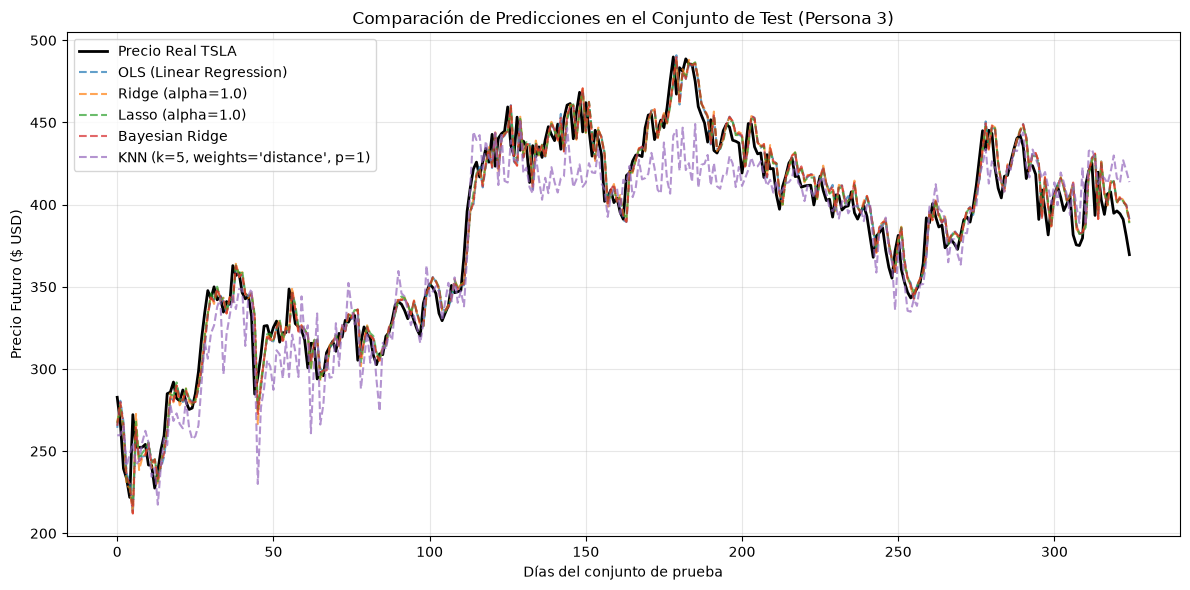

In [1]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Precio Real TSLA', color='black', linewidth=2)

for nombre, modelo in modelos.items():
    plt.plot(modelo.predict(X_test), label=nombre, alpha=0.7, linestyle='--')

plt.title('ComparaciÃ³n de Predicciones en el Conjunto de Test')
plt.xlabel('DÃ­as del conjunto de prueba')
plt.ylabel('Precio Futuro ($ USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## PARTE 5: PREDICCIÃ“N CON NUEVOS DATOS

In [ ]:
mejor_modelo = SVR(kernel="linear", C=1)
mejor_modelo.fit(X_train, y_train)

def predecir_precio_futuro(ruta_csv_nuevo, modelo, columnas_esperadas):
    """
    Recibe la ruta a un CSV nuevo (con el mismo formato/columnas que el dataset original,
    ya preprocesado y escalado igual que tsla_processed.csv) y devuelve las predicciones.
    """
    datos_nuevos = pd.read_csv(ruta_csv_nuevo)

    faltantes = set(columnas_esperadas) - set(datos_nuevos.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en el CSV nuevo: {faltantes}")

    X_nuevo = datos_nuevos[columnas_esperadas]
    predicciones = modelo.predict(X_nuevo)
    return predicciones

print("Modelo SVM lineal entrenado y listo para predicciones.")

Predicciones:
[635.44363108 637.28906841 732.76842034 ... 397.75576403 391.70744982
 380.67302293]


In [ ]:
X_test.head(5).to_csv("prueba.csv", index=False)

columnas = X_train.columns.tolist()
resultado = predecir_precio_futuro("prueba.csv", mejor_modelo, columnas)
valores_reales = y_test.head(5).values

print("Prueba de predicciÃ³n con 5 muestras:")
print("-" * 40)
for i in range(len(resultado)):
    print(f"PredicciÃ³n: ${resultado[i]:.2f} | Real: ${valores_reales[i]:.2f}")

PredicciÃ³n: 272.42
Valor real: 282.76
PredicciÃ³n: 277.12
Valor real: 267.28
PredicciÃ³n: 260.95
Valor real: 239.43
PredicciÃ³n: 233.98
Valor real: 233.29
PredicciÃ³n: 230.25
Valor real: 221.86


---
## DOCUMENTO DE INFRAESTRUCTURA DEL PROYECTO

### 1. GrÃ¡ficas del EDA
Las grÃ¡ficas del EDA se encuentran en la PARTE 2 de este notebook, incluyendo:
- EvoluciÃ³n del precio futuro
- DistribuciÃ³n y diagrama de caja del precio
- DistribuciÃ³n del retorno diario y volumen
- Matriz de correlaciÃ³n
- GrÃ¡ficas de dispersiÃ³n (close, precio_anterior, sma_5, volume vs precio_futuro)
- Volatilidad frente a retorno

### 2. ProporciÃ³n de entrenamiento y prueba
- **80% Entrenamiento:** 1,299 datos
- **20% Prueba:** 325 datos
- Se mantuvo el **orden cronolÃ³gico** (no aleatorio) ya que se trata de una serie de tiempo.
- ValidaciÃ³n cruzada con `TimeSeriesSplit(n_splits=5)`

### 3. DescripciÃ³n de los algoritmos de regresiÃ³n

| Modelo | DescripciÃ³n |
|---|---|
| **OLS** | MÃ­nimos cuadrados ordinarios. Encuentra la recta/plano que minimiza la suma de errores al cuadrado. |
| **Ridge** | RegresiÃ³n con regularizaciÃ³n L2. Reduce magnitud de coeficientes para evitar sobreajuste. |
| **Lasso** | RegresiÃ³n con regularizaciÃ³n L1. Puede eliminar features irrelevantes (coeficientes a 0). |
| **Bayesian Ridge** | Estima parÃ¡metros de regularizaciÃ³n mediante distribuciones a priori. |
| **KNN** | Predice usando el promedio ponderado de los k vecinos mÃ¡s cercanos en el espacio de features. |
| **Random Forest** | Ensemble de Ã¡rboles de decisiÃ³n. Cada Ã¡rbol aprende reglas y se promedian las predicciones. |
| **SVM** | Busca la funciÃ³n lineal/no lineal que mejor ajusta dentro de un margen de tolerancia. |
| **MLP** | Red neuronal totalmente conectada. Ajusta pesos mediante retropropagaciÃ³n. |

### 4. HiperparÃ¡metros empleados

| Modelo | HiperparÃ¡metros | Valor Ã“ptimo |
|---|---|---|
| Ridge | alpha | 1.0 |
| Lasso | alpha | 1.0 |
| KNN | n_neighbors, weights, p | 5, distance, 1 |
| Random Forest | n_estimators, max_depth | 100, 10 |
| SVM | kernel, C | linear, 1 |
| MLP | hidden_layer_sizes, learning_rate_init | (50,), 0.001 |

### 5. MÃ©tricas y estadÃ­sticas de rendimiento

| Modelo | MAE ($) | RMSE ($) | RÂ² |
|---|---|---|---|
| SVM (Linear) | 9.44 | 12.07 | 0.9574 |
| Lasso | 9.67 | 12.51 | 0.9543 |
| Bayesian Ridge | 9.92 | 12.92 | 0.9512 |
| OLS | 9.93 | 12.93 | 0.9511 |
| Ridge | 10.02 | 12.95 | 0.9510 |
| Random Forest | 10.11 | 13.12 | 0.9497 |
| MLP | 10.87 | 13.99 | 0.9428 |
| KNN | 16.57 | 21.53 | 0.8645 |

### 6. Funcionamiento del sistema de predicciÃ³n

El sistema de predicciÃ³n funciona de la siguiente manera:

1. **Entrenamiento:** El modelo SVM lineal se entrena con datos histÃ³ricos de TSLA (2020-2026) que incluyen 11 features escaladas.

2. **PredicciÃ³n:** La funciÃ³n `predecir_precio_futuro()` recibe un CSV con datos nuevos (ya preprocesados y escalados), valida que tenga las columnas correctas, y genera predicciones del precio del dÃ­a siguiente.

3. **Limitaciones:** Para evaluar con datos reales del dÃ­a actual, es necesario replicar el pipeline completo de preprocesamiento (medias mÃ³viles, retorno, volatilidad) y aplicar el mismo StandardScaler ajustado originalmente.

### 7. Notas tÃ©cnicas para la exposiciÃ³n

- **StandardScaler** se justifica porque SVM, KNN y MLP son sensibles a la escala de las variables.
- Las **medias mÃ³viles** y **volatilidad** son indicadores tÃ©cnicos comunes en anÃ¡lisis financiero.
- La **variable objetivo** es el precio del dÃ­a siguiente (horizonte de predicciÃ³n de 1 dÃ­a).
- Se usÃ³ **TimeSeriesSplit** para validaciÃ³n cruzada, evitando filtrar informaciÃ³n del futuro al pasado.